In [1]:
# This notebook was used to debug the parameter-mapping problem when converting 
# qiskit circuit to stim

In [2]:
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import random
import stim

from qiskit import transpile
from qiskit.circuit import Parameter,ParameterExpression
from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit_aer import AerSimulator
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit.converters import circuit_to_dag, dag_to_circuit
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeManilaV2,FakeNairobiV2,FakeMelbourneV2,FakeGuadalupeV2

import sys
sys.path.append("../")
from clapton.clapton import claptonize

from clapton.circuit_manipulation import transform_to_allowed_gates,qiskit_to_stim, modify_circuit, multi_angle_qaoa_circuit, generate_qiskit_param_map,relax_qaoa_parameters
from testing_scripts.graphs_utils import generate_random_complete_graph,generate_k_regular_graph,build_max_cut_paulis

In [3]:
n = 5
G = generate_random_complete_graph(num_vertices=n,weighted=True,seed=True)

max_cut_paulis = build_max_cut_paulis(G)

cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
print("Cost Function Hamiltonian:", cost_hamiltonian)
paulis,coeffs = cost_hamiltonian.paulis.to_labels(),cost_hamiltonian.coeffs.real

Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIZIZ', 'IZIIZ', 'ZIIIZ', 'IIZZI', 'IZIZI', 'ZIIZI', 'IZZII', 'ZIZII', 'ZZIII'],
              coeffs=[7.+0.j, 7.+0.j, 1.+0.j, 5.+0.j, 9.+0.j, 8.+0.j, 7.+0.j, 5.+0.j, 8.+0.j,
 6.+0.j])


In [4]:
reversed_paulis = [p[::-1] for p in paulis]

reps = 1
gamma_params = [Parameter(f'gamma_{i}_{j}_{r}') for r in range(reps) for i, j in G.edge_list()]
beta_params = [Parameter(f'beta_{i}_{r}') for r in range(reps) for i in G.node_indexes()]

circuit = multi_angle_qaoa_circuit(n,G ,reps)

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:1080: DeprecationWarning: The property ``qiskit.circuit.instruction.Instruction.condition`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  if getattr(op, "condition", None) or isinstance(op, SwitchCaseOp):


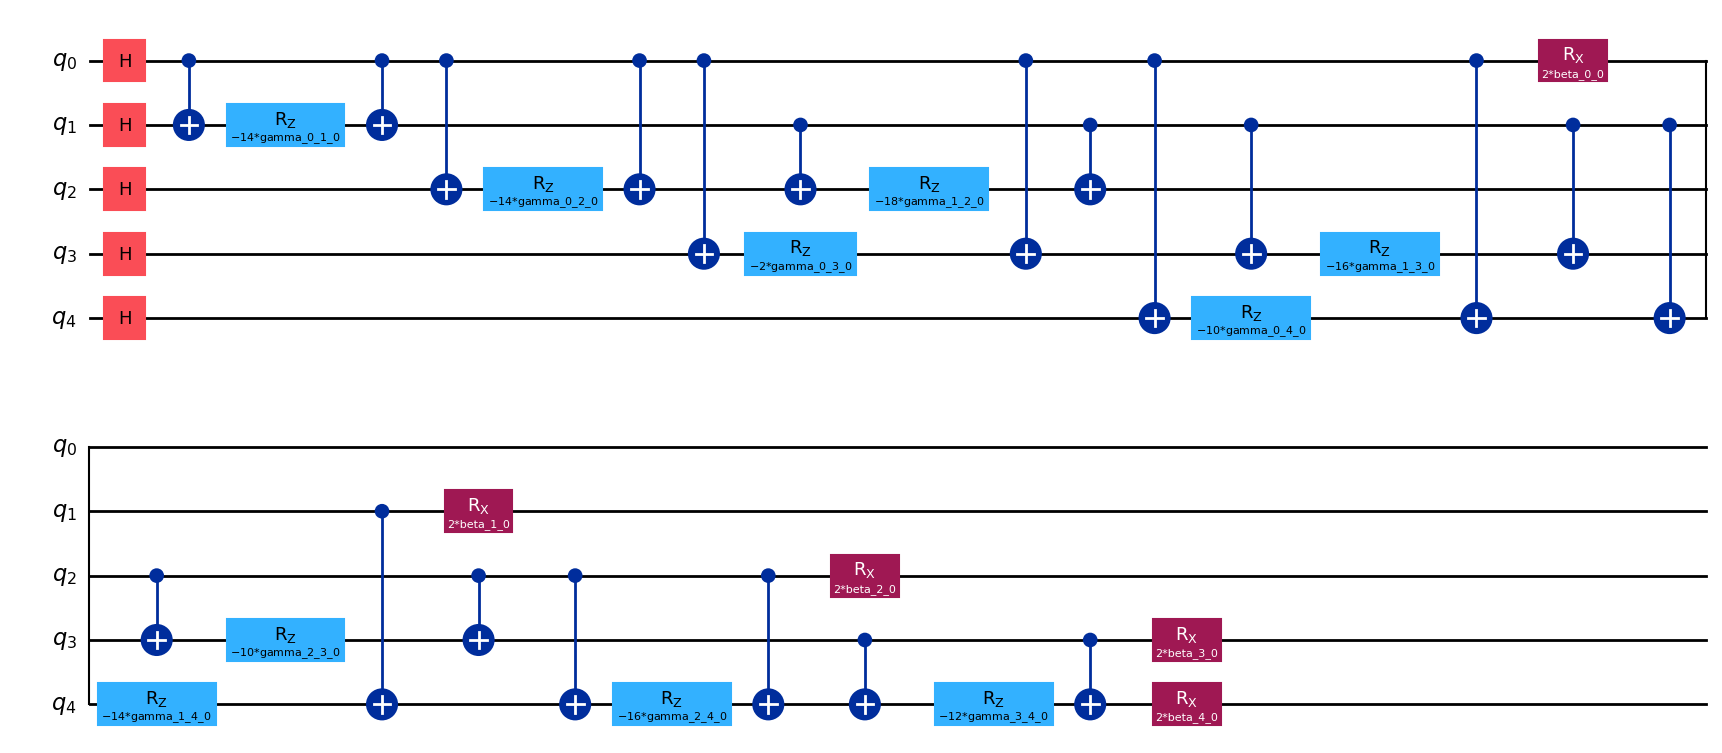

In [5]:
circuit.draw('mpl')

In [6]:
# Transform qiskit circ. to stim.
modified_circ = modify_circuit(circuit)
pcirc = transform_to_allowed_gates(modified_circ)

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/transpiler/passmanager.py:70: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.duration`` is deprecated as of qiskit 1.3.0. It will be removed in Qiskit 2.0.0.
  out_program = dag_to_circuit(passmanager_ir, copy_operations=False)
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/transpiler/passmanager.py:70: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.unit`` is deprecated as of qiskit 1.3.0. It will be removed in Qiskit 2.0.0.
  out_program = dag_to_circuit(passmanager_ir, copy_operations=False)
/global/u1/d/dhanvib/development/QAOA/playground_scripts/../clapton/circuit_manipulation.py:211: DeprecationWarning: Treating CircuitInstruction as an iterable is deprecated legacy behavior since Qiskit 1.2, and will be removed in Qiskit 2.0. Instead, use the `operation`, `qubits` and `clbits` named attributes.
  gate = in

In [7]:
# Usage
pcirc, dag , angle_multipliers= relax_qaoa_parameters(pcirc)

/global/u1/d/dhanvib/development/QAOA/playground_scripts/../clapton/circuit_manipulation.py:300: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.duration`` is deprecated as of qiskit 1.3.0. It will be removed in Qiskit 2.0.0.
  new_qc = dag_to_circuit(dag)
/global/u1/d/dhanvib/development/QAOA/playground_scripts/../clapton/circuit_manipulation.py:300: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.unit`` is deprecated as of qiskit 1.3.0. It will be removed in Qiskit 2.0.0.
  new_qc = dag_to_circuit(dag)


In [8]:
stim_circ = qiskit_to_stim(pcirc)
stim_circ.stim_circuit().diagram()

q0: -H-@---@-@---@-------@---@-------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------------------------------------------------------
       |   | |   |       |   |             |   |
q1: -H-X-I-X-|---|-@---@-|---|-@---@-------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------------------------------
             |   | |   | |   | |   |       |   |                   |   |
q2: -------H-X-I-X-X-I-X-|---|-|---|-@---@-|---|-------------------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------------------------------
                         |   | |   | |   | |   |                   |   |                   |   |
q3: -------------------H-X-I-X-X-I-X-X-I-X-|---|-------------------|---|-------------------|---|-------------------@---@-S-SQRT_X-I-SQRT_X-S-------------------
                                           |   |                   |   |                   |   |                   |   |
q4: -------------------------------------H-X-I-X-------------------X-I-X-------------------X-I-X-------------------X-I-X-------------------S-SQRT_X-I-SQRT_X-S-

/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/visualization/circuit/matplotlib.py:1080: DeprecationWarning: The property ``qiskit.circuit.instruction.Instruction.condition`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  if getattr(op, "condition", None) or isinstance(op, SwitchCaseOp):


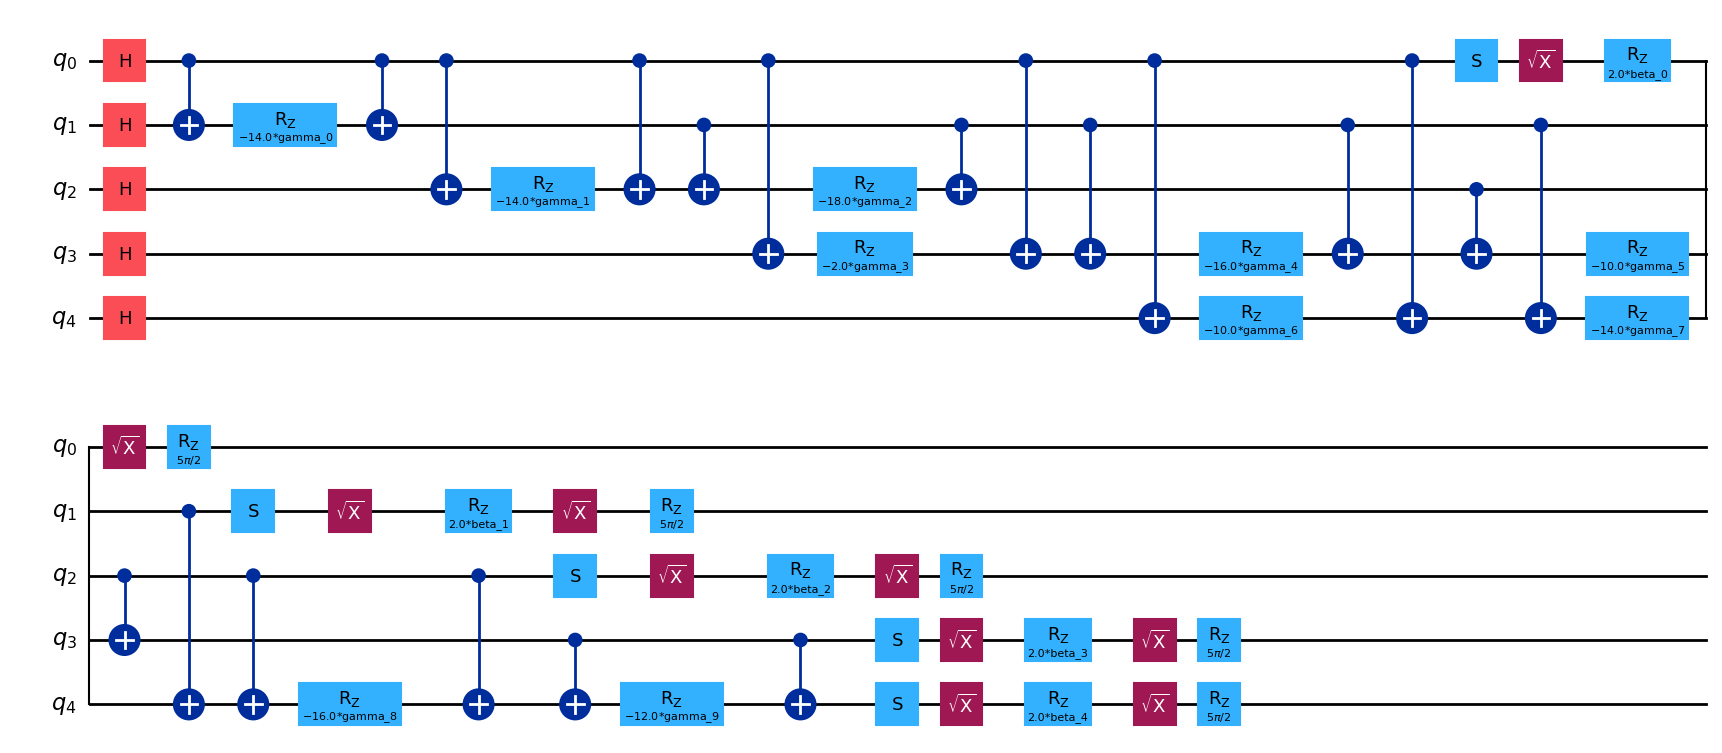

In [9]:
pcirc.draw('mpl')

In [ ]:
param_map = generate_qiskit_param_map(pcirc)
param_map

{0: 5,
 1: 6,
 2: 12,
 3: 0,
 4: 1,
 5: 8,
 6: 4,
 7: 10,
 8: 2,
 9: 3,
 10: 7,
 11: 9,
 12: 11,
 13: 13,
 14: 14}

In [11]:
pcirc.parameters

ParameterView([Parameter(-10.0*gamma_5), Parameter(-10.0*gamma_6), Parameter(-12.0*gamma_9), Parameter(-14.0*gamma_0), Parameter(-14.0*gamma_1), Parameter(-14.0*gamma_7), Parameter(-16.0*gamma_4), Parameter(-16.0*gamma_8), Parameter(-18.0*gamma_2), Parameter(-2.0*gamma_3), Parameter(2.0*beta_0), Parameter(2.0*beta_1), Parameter(2.0*beta_2), Parameter(2.0*beta_3), Parameter(2.0*beta_4)])

In [13]:
stim_circ.define_parameter_map(param_map)

In [14]:
angle_multipliers

{'-14.0*gamma_0': -14.0,
 '-14.0*gamma_1': -14.0,
 '-18.0*gamma_2': -18.0,
 '-2.0*gamma_3': -2.0,
 '-16.0*gamma_4': -16.0,
 '-10.0*gamma_5': -10.0,
 '-10.0*gamma_6': -10.0,
 '2.0*beta_0': 2.0,
 '-14.0*gamma_7': -14.0,
 '2.0*beta_1': 2.0,
 '-16.0*gamma_8': -16.0,
 '2.0*beta_2': 2.0,
 '-12.0*gamma_9': -12.0,
 '2.0*beta_3': 2.0,
 '2.0*beta_4': 2.0}

In [15]:
ks_best = []
random.seed(5) #100 is same , but #423
for i in range(pcirc.num_parameters):
    ks_best.append(random.randint(0, 3))

# ks_best = [1, 0, 0, 0, 0, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0]
# ks_best = [3] * (pcirc.num_parameters) ## Use this for same parameters
stim_circ.assign(ks_best)

In [ ]:
ordered_params = [param.name for param in pcirc.parameters]
mults = [np.pi / (2) for param in ordered_params]

cafqa_angles = [param * mult for param,mult in zip(ks_best,mults)]
init_params = cafqa_angles

In [17]:
def cafqa_params_energy(circuit, hamiltonian, parameters):
    estimator = Estimator(mode=AerSimulator(method='statevector'))
    isa_hamiltonian = hamiltonian.apply_layout(circuit.layout)

    pub = (circuit,isa_hamiltonian, parameters)
    job = estimator.run([pub])

    results = job.result()[0]
    return results.data.evs

energies = [cafqa_params_energy(pcirc, cost_hamiltonian, init_params) for _ in range(10)]
average_qiskit_energy = np.mean(energies)


/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/transpiler/passmanager.py:70: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.duration`` is deprecated as of qiskit 1.3.0. It will be removed in Qiskit 2.0.0.
  out_program = dag_to_circuit(passmanager_ir, copy_operations=False)
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit/transpiler/passmanager.py:70: DeprecationWarning: The property ``qiskit.dagcircuit.dagcircuit.DAGCircuit.unit`` is deprecated as of qiskit 1.3.0. It will be removed in Qiskit 2.0.0.
  out_program = dag_to_circuit(passmanager_ir, copy_operations=False)
/global/homes/d/dhanvib/.conda/envs/qaoa_w_sage/lib/python3.10/site-packages/qiskit_aer/backends/aer_compiler.py:695: DeprecationWarning: The property ``qiskit.circuit.instruction.Instruction.condition`` is deprecated as of qiskit 1.3.0. It will be removed in 2.0.0.
  or getattr(inst.operation, "condition", None)
/global/h

In [18]:
print("Average Energy over 100 runs:", average_qiskit_energy)

Average Energy over 100 runs: -7.897216796875


In [19]:
def stim_exp_val(stim_qc,paulis,coeffs):
    sim = stim.TableauSimulator()
    sim.do_circuit(stim_qc)
    pauli_expect = [sim.peek_observable_expectation(stim.PauliString(p)) for p in paulis] #need paulis
    loss = np.inner(coeffs, pauli_expect)
    return loss

losses = [stim_exp_val(stim_circ.stim_circuit(), reversed_paulis, coeffs) for _ in range(10)]
average_stim_energy = np.mean(losses)
print("Average Loss over 100 runs:", average_stim_energy)

Average Loss over 100 runs: -8.0


In [20]:
ks_best,stim_circ.internal_read()

([2, 2, 0, 3, 1, 0, 1, 0, 2, 3, 1, 3, 0, 1, 0],
 [3, 1, 2, 3, 1, 2, 2, 1, 0, 3, 0, 0, 0, 1, 0])